In [4]:
from astropy.io import fits
import numpy as np

In [91]:
with fits.open("4C1971_G235H_NRS1_NRS2_s3d.fits") as hdul:
    hdul.info()
    data = hdul[1].data
    print(np.any(hdul[3].data))
    mask = np.isnan(data) | (data > 100)
    hdul[3].data = mask.astype(np.float64)
    hdul.writeto("4C1971_with_data_quality.fits", overwrite=True)

Filename: 4C1971_G235H_NRS1_NRS2_s3d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     374   ()      
  1  SCI           1 ImageHDU        34   (70, 83, 3815)   float64   
  2  SCI           1 ImageHDU        34   (70, 83, 3815)   float64   
  3                1 ImageHDU         8   (70, 83, 3815)   float64   
False


In [5]:
with fits.open("4C1971_with_data_quality.fits") as hdul:
    hdul.info()
    data = hdul[1].data

Filename: 4C1971_with_data_quality.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     374   ()      
  1  SCI           1 ImageHDU        34   (70, 83, 3815)   float64   
  2  SCI           1 ImageHDU        34   (70, 83, 3815)   float64   
  3                1 ImageHDU         8   (70, 83, 3815)   float64   


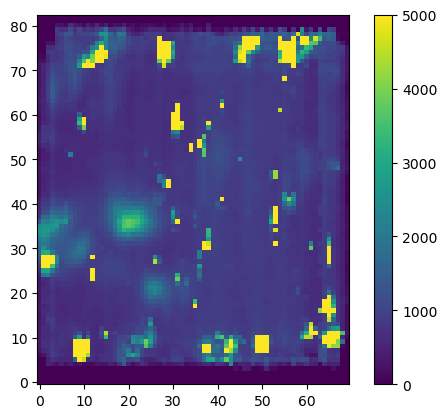

In [6]:
import matplotlib.pyplot as plt
plt.imshow(np.nansum(data, axis=0), vmin=0, vmax=5000, origin="lower")
plt.colorbar()

(8, 7)

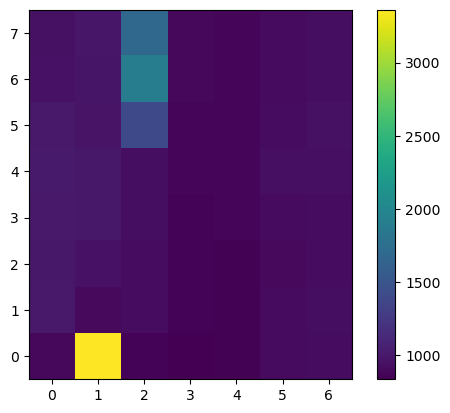

In [10]:
img = np.nansum(data[:, 18:26, 34:41], axis=0)
plt.imshow(img, origin="lower")
plt.colorbar()
img.shape

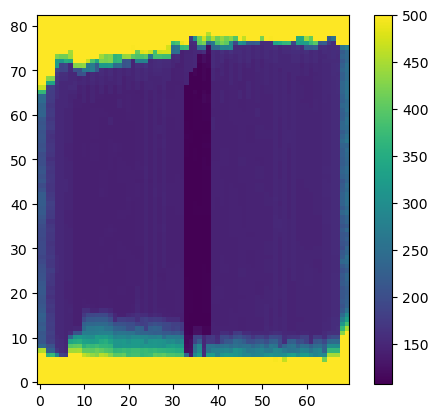

In [75]:
nan_mask = np.isnan(data).astype(int)
plt.imshow(np.sum(nan_mask, axis=0), vmax=500, origin="lower")
plt.colorbar()

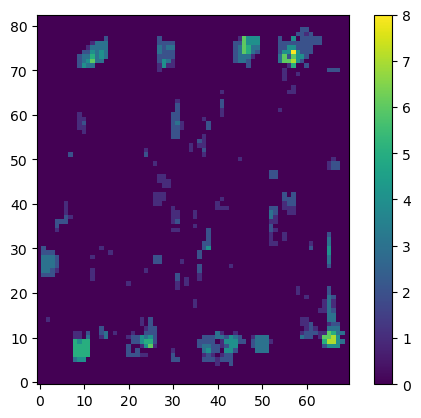

In [79]:
peak_mask = (data > 100).astype(int)
plt.imshow(np.sum(peak_mask, axis=0), origin="lower")
plt.colorbar()

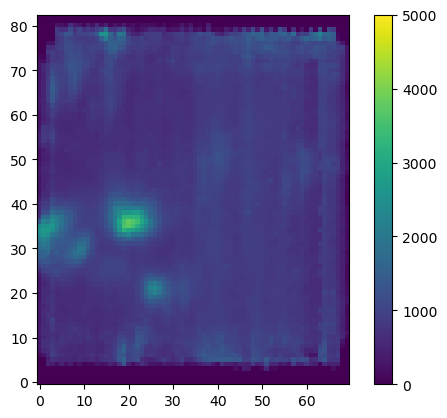

In [84]:
plt.imshow(np.sum(np.where(peak_mask | nan_mask, 0, data), axis=0), vmin=0, vmax=5000, origin="lower")
plt.colorbar()

In [85]:
mask = peak_mask | nan_mask